# Visualize Segmentation Results

This notebook loads a trained model from `runs/`, runs inference on samples from `data/splits`,
and visualizes input images, ground-truth masks, and predictions.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image


2026-01-10 20:44:34.623424: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-10 20:44:34.660567: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-10 20:44:35.379791: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/huay/Projects/PBL4/venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:

In [ ]:
PROJECT_ROOT = Path(".").resolve()
RUNS_DIR = PROJECT_ROOT / "runs"
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"

RUN_NAME = "nestnet-resnet18"  # change if you trained a different model
MODEL_PATH = RUNS_DIR / RUN_NAME / "best.keras"
SPLIT = "val"  # train | val | test
NUM_SAMPLES = 6
SEED = 13
DEFAULT_INPUT_SIZE = (512, 1024)  # (H, W)

In [3]:
def load_class_map(path):
    entries = []
    if not Path(path).exists():
        return entries
    for line in Path(path).read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        if len(parts) == 1:
            name, idx = parts[0], int(parts[0])
        else:
            name, idx = parts[0], int(parts[-1])
        entries.append((name, idx))
    return entries


def infer_num_classes(class_map_entries):
    if not class_map_entries:
        return 1
    max_id = max(idx for _, idx in class_map_entries)
    return max_id + 1


def build_colormap(num_classes, seed=13):
    rng = np.random.default_rng(seed)
    colors = rng.uniform(0.0, 1.0, size=(num_classes, 3))
    colors[0] = 0.0
    return colors


def list_pairs(images_dir, masks_dir):
    images_dir = Path(images_dir)
    masks_dir = Path(masks_dir)
    masks = {p.stem: p for p in masks_dir.glob("*.png")}
    image_paths = []
    for ext in (".jpg", ".jpeg", ".png"):
        image_paths.extend(images_dir.glob(f"*{ext}"))
    pairs = []
    for img in sorted(image_paths):
        mask = masks.get(img.stem)
        if mask is not None:
            pairs.append((img, mask))
    return pairs


def load_image(path, size=None):
    img = Image.open(path).convert("RGB")
    if size is not None:
        img = img.resize((size[1], size[0]), resample=Image.BILINEAR)
    return np.asarray(img).astype(np.float32) / 255.0


def load_mask(path, size=None):
    mask = Image.open(path)
    if size is not None:
        mask = mask.resize((size[1], size[0]), resample=Image.NEAREST)
    arr = np.asarray(mask)
    if arr.ndim == 3:
        arr = arr[..., 0]
    return arr.astype(np.int32)


def predict_mask(model, image):
    pred = model.predict(image[None, ...], verbose=0)
    if pred.shape[-1] == 1:
        return (pred[0, ..., 0] > 0.5).astype(np.int32)
    return np.argmax(pred[0], axis=-1).astype(np.int32)


def overlay_mask(image, mask, colors, alpha=0.5):
    colored = colors[mask]
    return np.clip((1.0 - alpha) * image + alpha * colored, 0.0, 1.0)

In [4]:
if not MODEL_PATH.exists():
    raise SystemExit(f"Model not found: {MODEL_PATH}")

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
input_shape = model.input_shape
if isinstance(input_shape, list):
    input_shape = input_shape[0]

if input_shape[1] and input_shape[2]:
    input_size = (int(input_shape[1]), int(input_shape[2]))
else:
    input_size = DEFAULT_INPUT_SIZE

class_map_entries = load_class_map(SPLITS_DIR / "class_map.txt")
num_classes = infer_num_classes(class_map_entries)
colors = build_colormap(num_classes)

print("Model:", MODEL_PATH)
print("Input size:", input_size)
print("Classes:", num_classes)

I0000 00:00:1768052675.810022   26991 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6095 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: /home/huay/Projects/PBL4/runs/unet-resnet18/best.keras
Input size: (512, 1024)
Classes: 33


2026-01-10 20:44:37.486237: I external/local_xla/xla/service/service.cc:163] XLA service 0x70201c01abc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-10 20:44:37.486254: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Laptop GPU, Compute Capability 8.6
2026-01-10 20:44:37.514569: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-10 20:44:37.728109: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-01-10 20:44:38.149232: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-10 20:44:38.269874: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel 

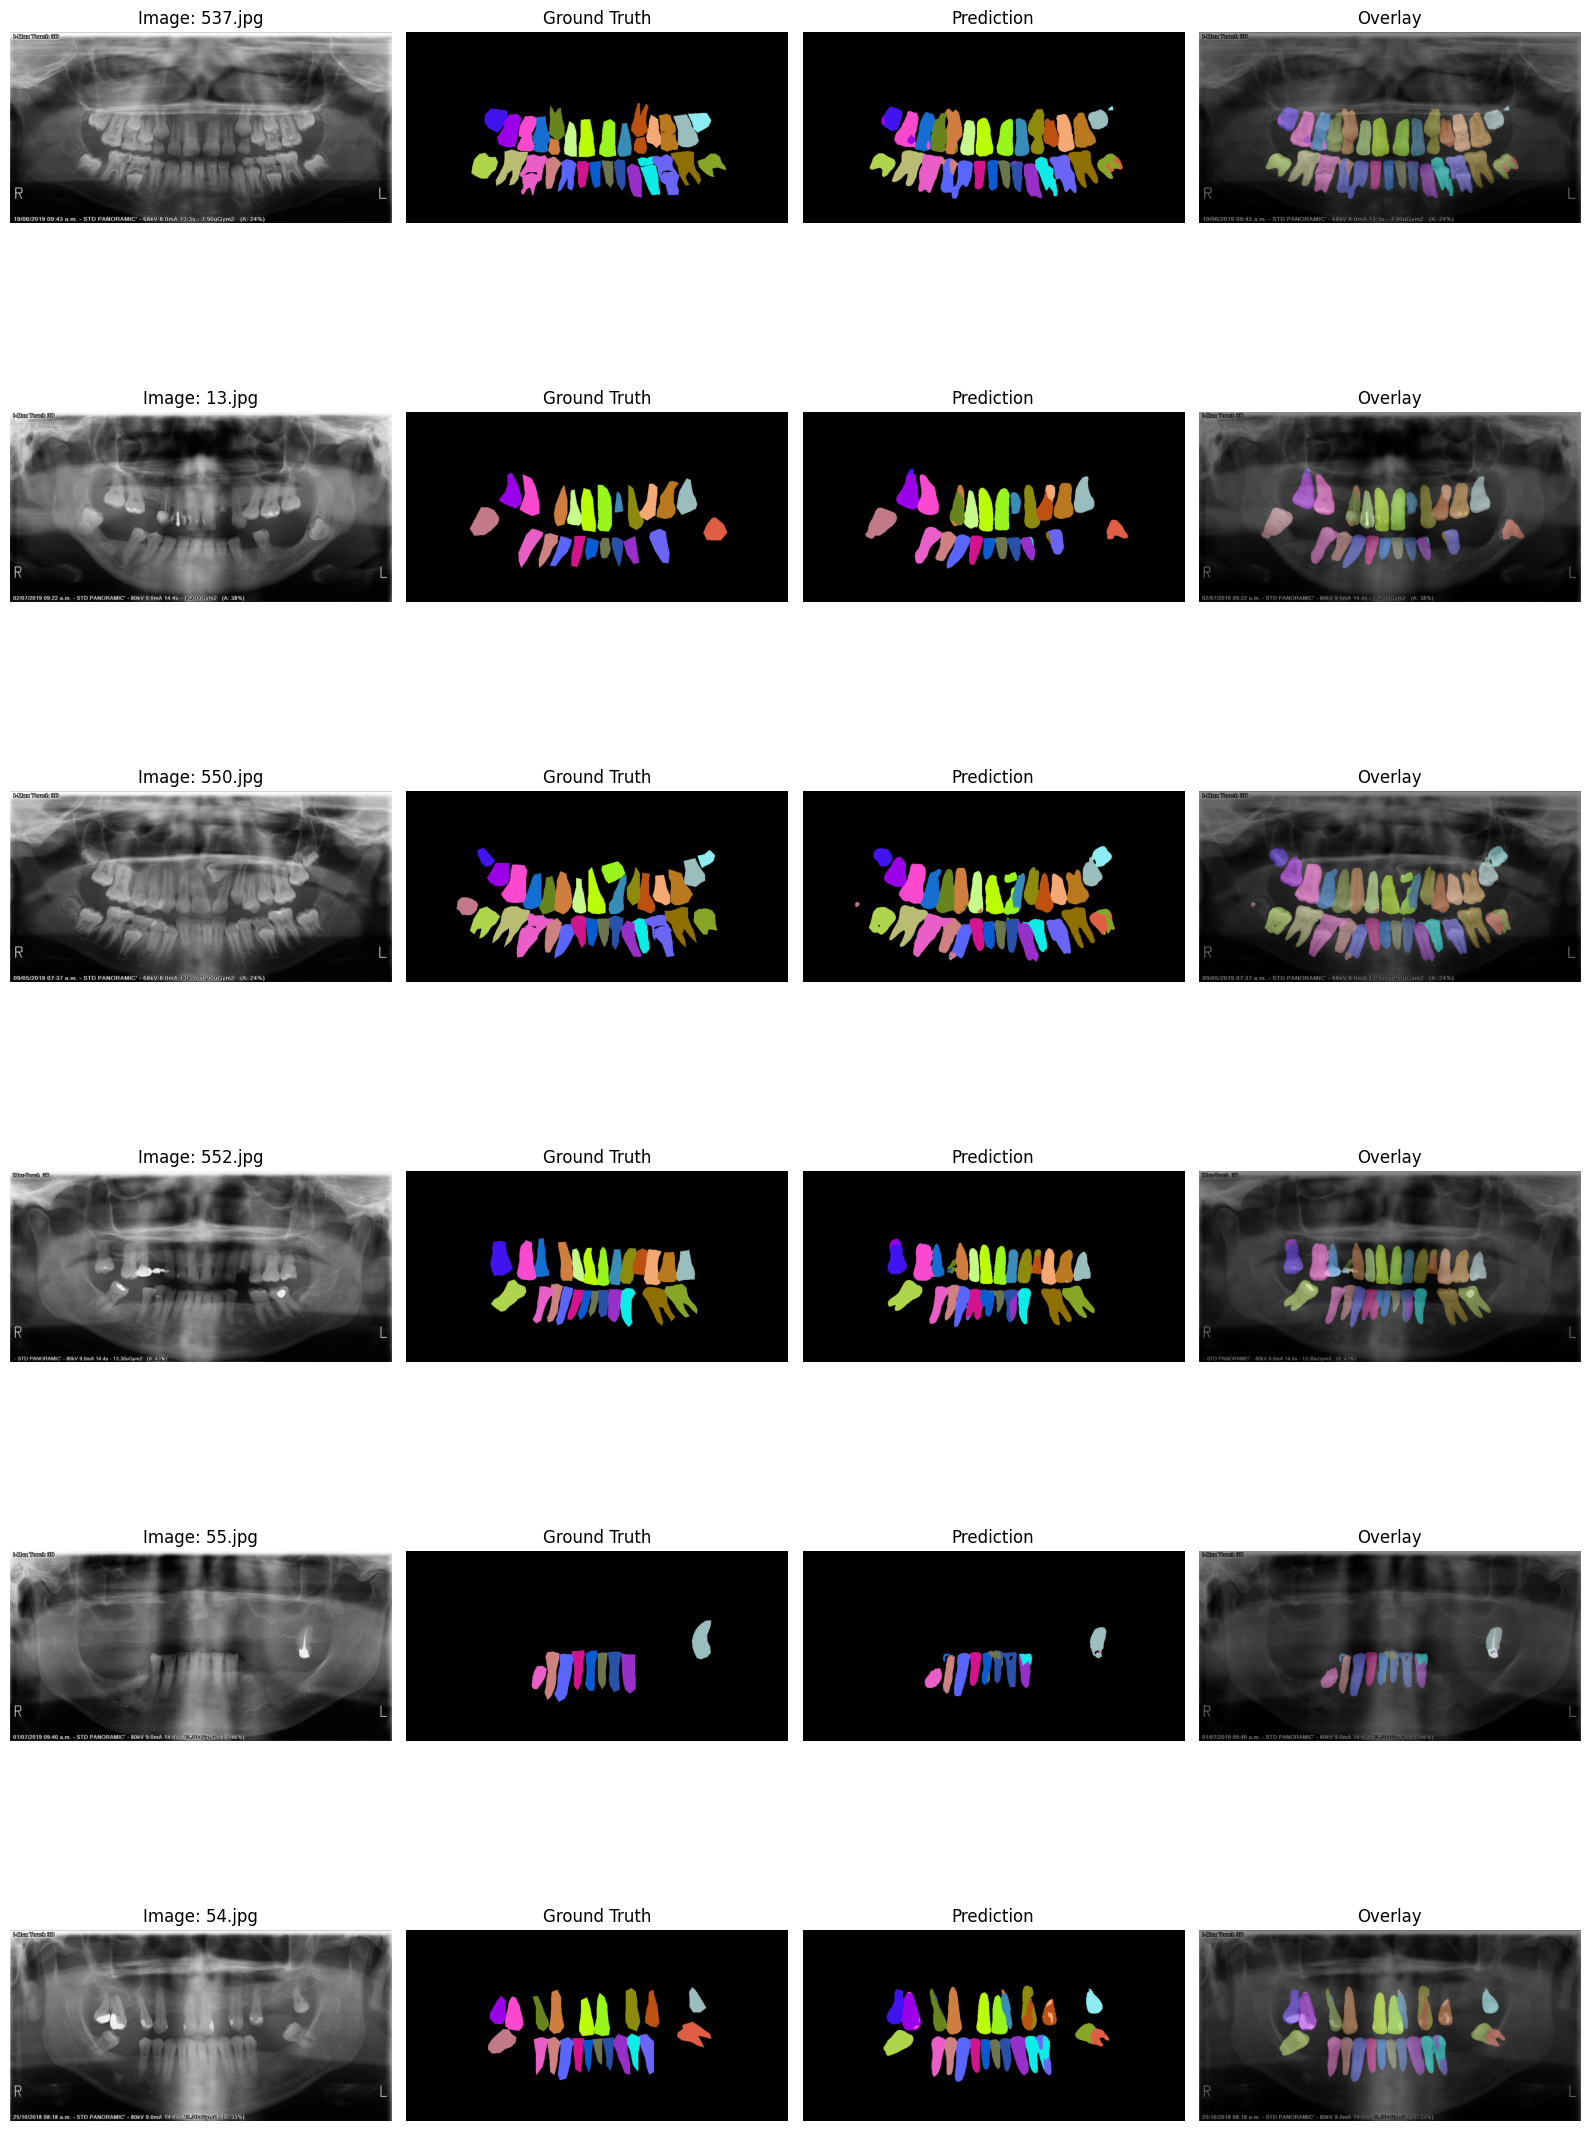

In [5]:
pairs = list_pairs(SPLITS_DIR / SPLIT / "img", SPLITS_DIR / SPLIT / "masks_semantic")
if not pairs:
    raise SystemExit(f"No image/mask pairs found in {SPLITS_DIR / SPLIT}")

rng = np.random.default_rng(SEED)
indices = rng.choice(len(pairs), size=min(NUM_SAMPLES, len(pairs)), replace=False)

fig, axes = plt.subplots(len(indices), 4, figsize=(16, 4 * len(indices)))
if len(indices) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, idx in enumerate(indices):
    img_path, mask_path = pairs[idx]
    image = load_image(img_path, input_size)
    mask = load_mask(mask_path, input_size)
    pred_mask = predict_mask(model, image)

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f"Image: {img_path.name}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(colors[mask])
    axes[row, 1].set_title("Ground Truth")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(colors[pred_mask])
    axes[row, 2].set_title("Prediction")
    axes[row, 2].axis("off")

    axes[row, 3].imshow(overlay_mask(image, pred_mask, colors, alpha=0.45))
    axes[row, 3].set_title("Overlay")
    axes[row, 3].axis("off")

plt.tight_layout()
plt.show()